Saving Resume.csv to Resume.csv
Dataset Loaded!
         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  
2  <div class="fontsize fontface vmargins hmargin...       HR  
3  <div class="fontsize fontface vmargins hmargin...       HR  
4  <div class="fontsize fontface vmargins hmargin...       HR  

Classification Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.70      0.79      0.75        24
              ADVO

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


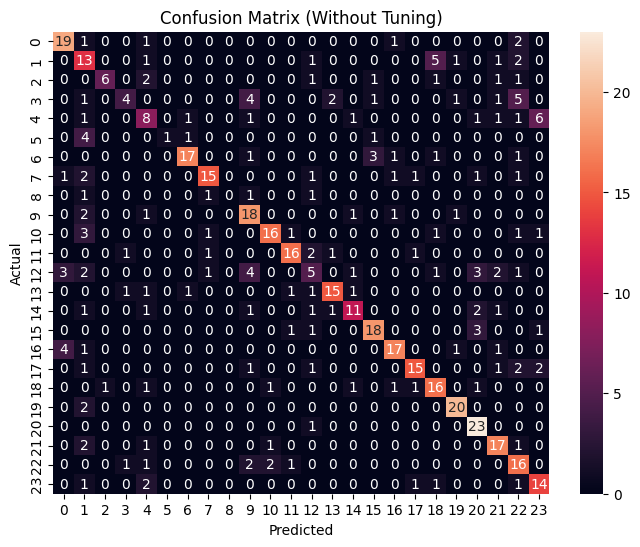

In [ ]:
# =========================
# Resume Classification (SVM - No Tuning)
# =========================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# =========================
# Upload File (Colab)
# =========================
from google.colab import files
files.upload()

# =========================
# Load Dataset
# =========================
file_path = 'Resume.csv'

if not os.path.exists(file_path):
    raise FileNotFoundError("Resume.csv not found! Check upload.")

df = pd.read_csv(file_path)

print("Dataset Loaded!")
print(df.head())

# =========================
# Column Detection
# =========================
text_column = [col for col in df.columns if "resume" in col.lower()][0]
label_column = [col for col in df.columns if "category" in col.lower()][0]

X = df[text_column]
y = df[label_column]

# =========================
# Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# TF-IDF
# =========================
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# =========================
# Model Training (Simple SVM)
# =========================
model = SVC(kernel='linear', probability=True, random_state=42)
model.fit(X_train_tfidf, y_train)

# =========================
# Prediction
# =========================
y_pred = model.predict(X_test_tfidf)

# =========================
# Evaluation
# =========================
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Without Tuning)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Saving Resume.csv to Resume.csv
Dataset Loaded!
         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  
2  <div class="fontsize fontface vmargins hmargin...       HR  
3  <div class="fontsize fontface vmargins hmargin...       HR  
4  <div class="fontsize fontface vmargins hmargin...       HR  
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}

Classification Report:
                    

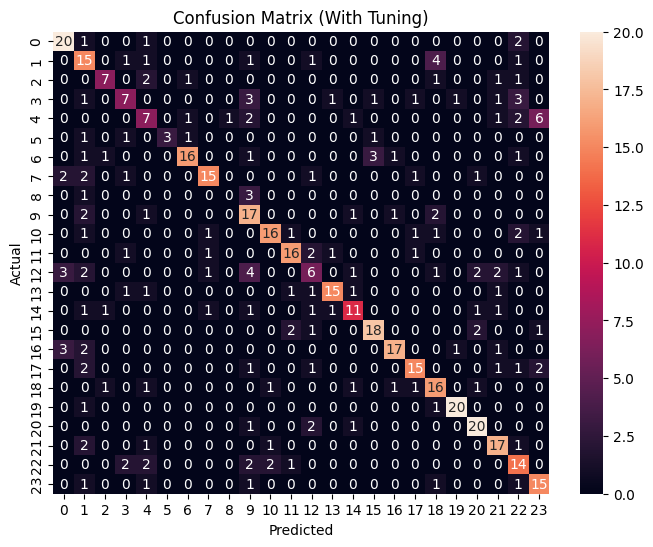

In [ ]:
# =========================
# Resume Classification (SVM + Hyperparameter Tuning)
# =========================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# =========================
# Upload File (Colab)
# =========================
from google.colab import files
files.upload()

# =========================
# Load Dataset
# =========================
file_path = 'Resume.csv'

if not os.path.exists(file_path):
    raise FileNotFoundError("Resume.csv not found! Check upload.")

df = pd.read_csv(file_path)

print("Dataset Loaded!")
print(df.head())

# =========================
# Column Detection
# =========================
text_column = [col for col in df.columns if "resume" in col.lower()][0]
label_column = [col for col in df.columns if "category" in col.lower()][0]

X = df[text_column]
y = df[label_column]

# =========================
# Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# TF-IDF
# =========================
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# =========================
# Hyperparameter Grid
# =========================
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# =========================
# GridSearchCV
# =========================
grid = GridSearchCV(
    SVC(probability=True),
    param_grid,
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train_tfidf, y_train)

print("\nBest Parameters:", grid.best_params_)

# =========================
# Best Model
# =========================
best_model = grid.best_estimator_

# =========================
# Prediction
# =========================
y_pred = best_model.predict(X_test_tfidf)

# =========================
# Evaluation
# =========================
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (With Tuning)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()